# Plotting Shapefiles

This notebook demonstrates how to plot shapefile data using `gplately`. In geology, shapefiles are a standard format for storing and exchanging geospatial vector data such as points, lines, and polygons. They are widely used in GIS and geological modeling to represent features like fault lines, geological boundaries, sample locations, or basin outlines.

### Setup

Let’s start by importing the required packages.

In [1]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygplates cartopy geopandas matplotlib pandas numpy` if not already installed.
import gplately
from plate_model_manager import PlateModelManager
import pygplates
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

2025-09-29 16:44:06 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.
2025-09-29 16:44:15 - gplately - ERROR - Failed to import PyGMT. PyGMT requires Python>=3.11.


Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

We then extract individual layers from the model:

- Coastlines: for reconstructing ancient shorelines.

- ContinentalPolygons: for plotting continental outlines.

- COBs (Continent-Ocean Boundaries): useful for defining the transition between land and oceanic crust.

Finally, we create a `PlotTopologies object (gplot)`, which simplifies visualizing reconstructed features like plate boundaries, continents, and COBs at any geological time.

In [2]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time_ma = 100  # Ma (Million years ago)

### Importing Shapefile Data

Here, we plot a .shp file from the [Global Seafloor Fabric (GSFML) database](https://gsfml.earthbyte.org/SF/index.html), which contains mapped fracture zones. The dataset was compiled by P. Wessel, R. D. Müller, and collaborators and provides a global view of present-day seafloor tectonic fabric. Using `pygplates.FeatureCollection`, we can access all vector features in the shapefile, such as fracture zones, and manipulate or visualize them in Python.

In [3]:
# ---- Load the .shp file ----
# Update with your shapefile path
shapefile_path = "../../data/SHP/GSFML_SF_FZ_RM.shp"

shapefile_features = pygplates.FeatureCollection(shapefile_path)

### Plotting & Reconstructing 

This code shows how to visualize coastlines in two ways:

1. As they appear today (from a static shapefile):

    - Plots the coastlines on a global map in blue, showing the modern configuration of continents using `gplot` ([PlotTopologies object](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html)).

2. As they looked 100 Ma, using a plate tectonic reconstruction model:

    - If the shapefile features lack plate IDs, they are first assigned to plates using `pygplates.partition_into_plates()`, which determines which tectonic plate each feature belongs to based on its spatial relationship with the plate polygons.
    
    - The assigned features are then reconstructed back to 100 Ma using the plate rotation model.
    
    - Finally, the reconstructed coastlines are plotted, visualizing how the continents and oceanic boundaries were distributed at that time in Earth’s geological history.

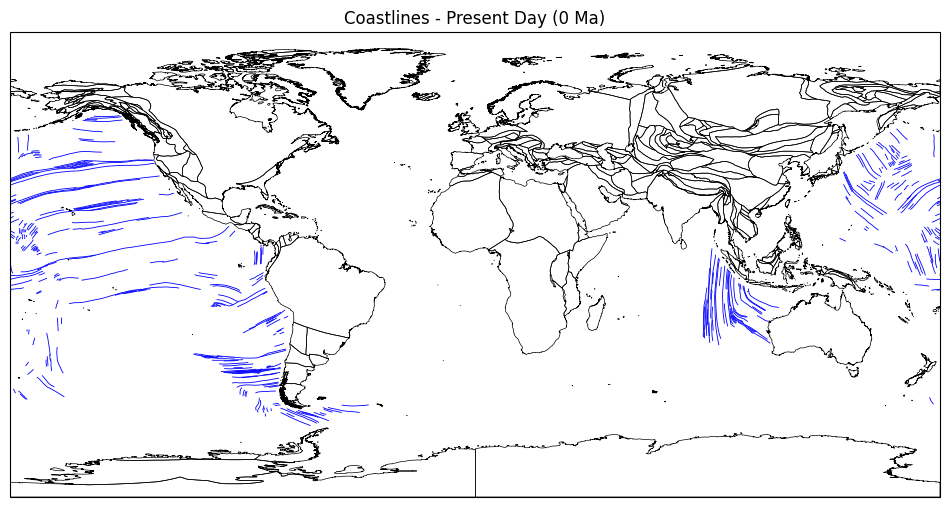

In [8]:
# --- PLOT 1: Present Day (0 Ma) ---
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

gplot.time = 0

# Plot present-day coastlines using PlotTopologies object
gplot.plot_feature(
    ax,
    shapefile_features,
    color='blue',
    linewidth=0.6
)

gplot.plot_coastlines(ax, color='black', linewidth=0.5)

plt.title('Coastlines - Present Day (0 Ma)')
plt.show()

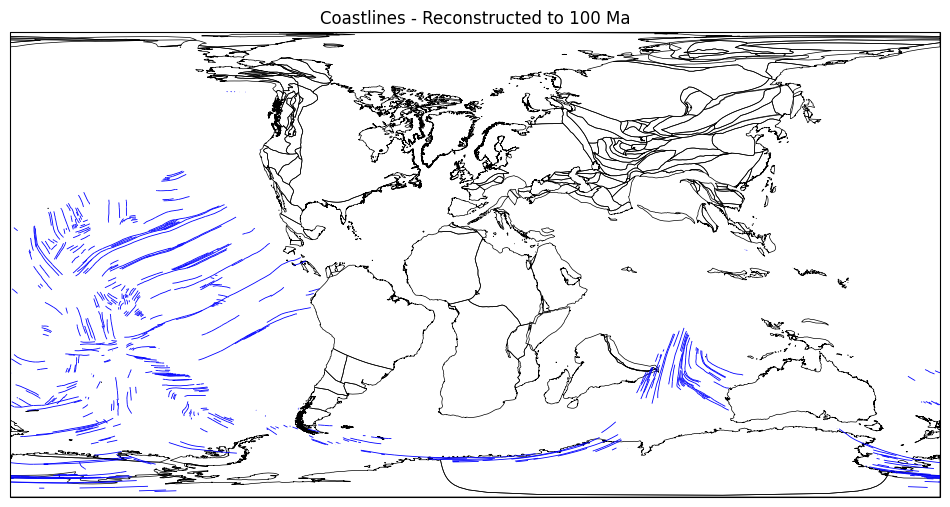

In [12]:
# --- PLOT 2: Reconstructed to 100 Ma ---

# If they lack plate IDs, we need to assign them
# This assigns them to appropriate plates based on their location
assigned_features = pygplates.partition_into_plates(
    static_polygons_filename,
    rotation_model,
    shapefile_features
)

# Now reconstruct with the assigned features
reconstructed_features = model.reconstruct(
    assigned_features,
    to_time=time_ma
)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

gplot.time = time_ma

# Plot reconstructed coastlines using PlotTopologies object
gplot.plot_feature(
    ax,
    reconstructed_features,     # Reconstructed coastlines
    color='blue',
    linewidth=0.6
)

gplot.plot_coastlines(ax, color='black', linewidth=0.5)

plt.title(f'Coastlines - Reconstructed to {time_ma} Ma')
plt.show()